<a href="https://colab.research.google.com/github/aadrikamishra/Git_demo/blob/master/bootcamyear1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks)): # Changed from len(marks) - 1 to len(marks)
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")

print("Average:", average)

Class passed
Average: 61.0


In [ ]:
import pandas as pd

In [ ]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [ ]:
df.shape

(6, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [ ]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [ ]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [ ]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [ ]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


### Data Visualization

Let's visualize some aspects of the student data to gain more insights. We'll use `matplotlib` and `seaborn` for plotting.

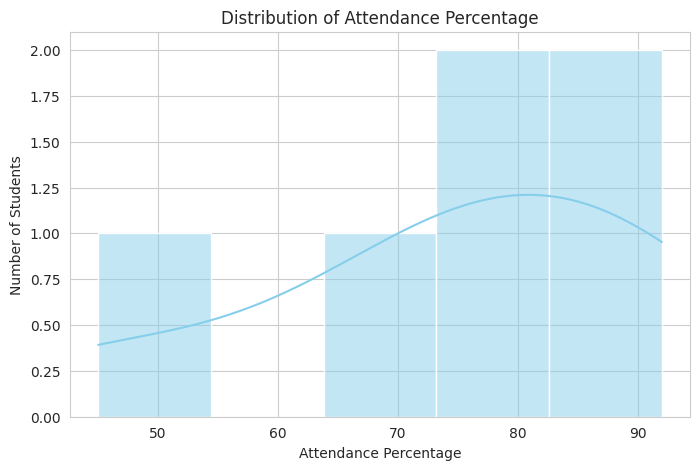

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Plot the distribution of attendance percentage
plt.figure(figsize=(8, 5))
sns.histplot(df['attendance_percent'], kde=True, bins=5, color='skyblue')
plt.title('Distribution of Attendance Percentage')
plt.xlabel('Attendance Percentage')
plt.ylabel('Number of Students')
plt.show()

This histogram shows the frequency of students within different attendance percentage ranges. You can see how many students fall into each attendance bracket.

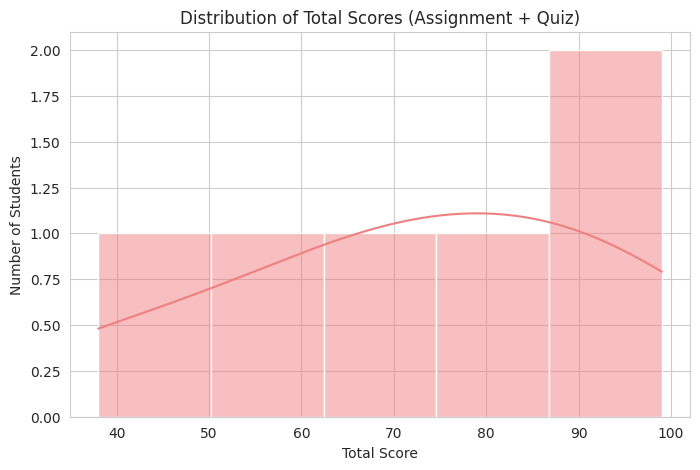

In [ ]:
# Plot the distribution of total scores
plt.figure(figsize=(8, 5))
sns.histplot(df['total_score'], kde=True, bins=5, color='lightcoral')
plt.title('Distribution of Total Scores (Assignment + Quiz)')
plt.xlabel('Total Score')
plt.ylabel('Number of Students')
plt.show()

Similarly, this histogram illustrates the distribution of the combined assignment and quiz scores among the students.

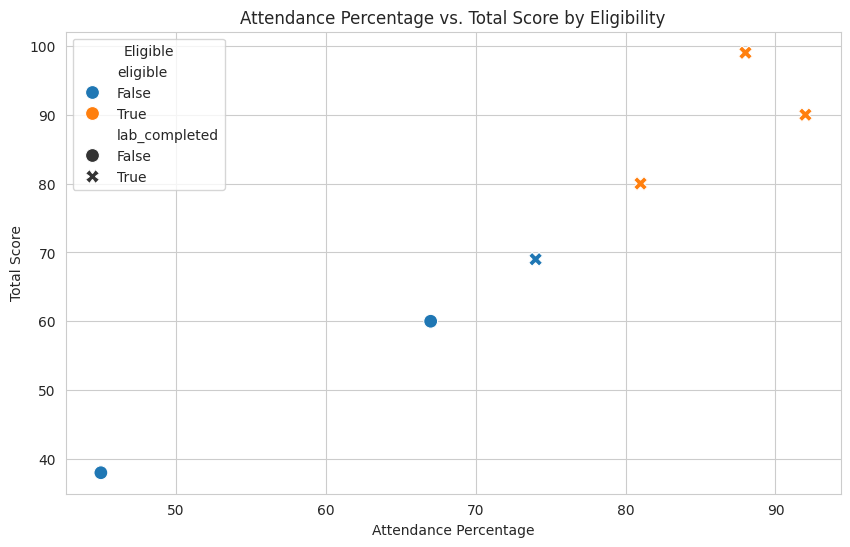

In [ ]:
# Scatter plot of Attendance vs Total Score, colored by eligibility
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='attendance_percent', y='total_score', hue='eligible', style='lab_completed', s=100) # s for size of markers
plt.title('Attendance Percentage vs. Total Score by Eligibility')
plt.xlabel('Attendance Percentage')
plt.ylabel('Total Score')
plt.legend(title='Eligible')
plt.show()

This scatter plot helps visualize the relationship between attendance percentage and total score. The points are colored based on `eligible` status and styled by `lab_completed`, allowing you to see how these factors interact.

/tmp/ipykernel_3775/3367507586.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='eligible', palette='viridis')


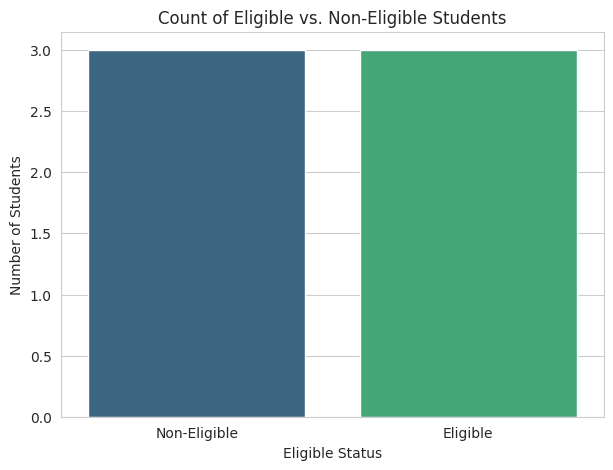

In [ ]:
# Count of eligible vs non-eligible students
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='eligible', palette='viridis')
plt.title('Count of Eligible vs. Non-Eligible Students')
plt.xlabel('Eligible Status')
plt.ylabel('Number of Students')
plt.xticks([0, 1], ['Non-Eligible', 'Eligible'])
plt.show()

### Additional Visualizations

In [ ]:
# Pie Chart for Eligibility
plt.figure(figsize=(8, 8))
df['eligible'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral'])
plt.title('Proportion of Eligible vs. Non-Eligible Students')
plt.ylabel('') # Hide the y-label for a cleaner look
plt.show()

This pie chart visually represents the percentage of students who are eligible versus those who are not, based on your defined criteria.

In [ ]:
# Area Chart: Cumulative Performance Look (Cumulative Distribution of Total Scores)

# Sort the DataFrame by 'total_score'
df_sorted_score = df.sort_values(by='total_score').reset_index(drop=True)

# Calculate cumulative count of students
df_sorted_score['cumulative_students'] = df_sorted_score.index + 1

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_sorted_score, x='total_score', y='cumulative_students', drawstyle='steps-pre')
plt.fill_between(df_sorted_score['total_score'], df_sorted_score['cumulative_students'], color='skyblue', alpha=0.4)
plt.title('Cumulative Number of Students by Total Score')
plt.xlabel('Total Score')
plt.ylabel('Cumulative Number of Students')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This area chart shows the cumulative number of students as the total score increases. For instance, you can see how many students have a total score of 'X' or less. This helps in understanding performance distribution thresholds.

This bar plot provides a clear count of how many students meet the eligibility criteria versus those who do not.